In [97]:
# generate data

In [98]:
import numpy as np
true_b = 1
true_w = 2
N = 200
np.random.seed(42)
x = np.random.randn(N,1)
e = np.random.randn(N,1) * .2
y = true_b + true_w * x + e
y.shape

(200, 1)

### plot the dataset

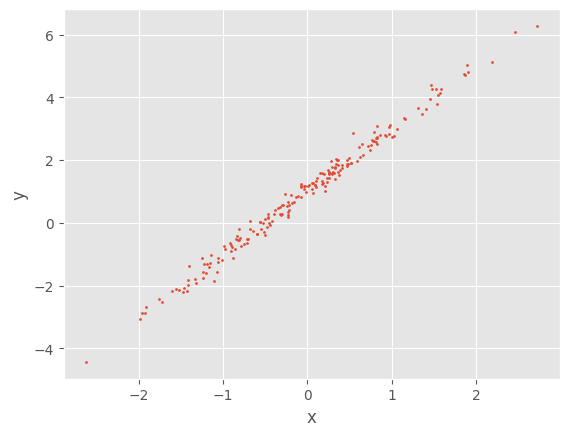

In [99]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.scatter(x,y,s=2)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

### split data to train, test

### initialize b,w

In [100]:
np.random.seed(1)
b = np.random.randn(1)
w = np.random.randn(1)
b,w

(array([1.62434536]), array([-0.61175641]))

In [101]:
y_pred = b + w * x

Text(0, 0.5, 'y')

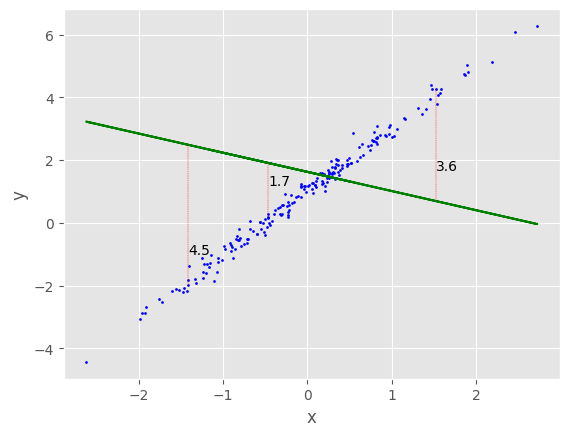

In [102]:
plt.scatter(x,y,s=2,c = 'b')
plt.plot(x,y_pred, c = 'g')
for i in [3,10,100]:
    ymin = min([y_pred[i],y[i]])
    ymax = max([y_pred[i],y[i]])
    plt.vlines(x = x[i],ymin = ymin, ymax = ymax,
              colors = 'r',
              label = 'error',
              linestyle = '--',
              linewidth = .3)
    plt.annotate(f'{(ymax - ymin)[0]:0.1f}',xy = (x[i], ymin + 1))
plt.xlabel('x')
plt.ylabel('y')

In [103]:
error = y_pred - y
loss = .5*(error ** 2).mean()
loss

np.float64(3.260929222076153)

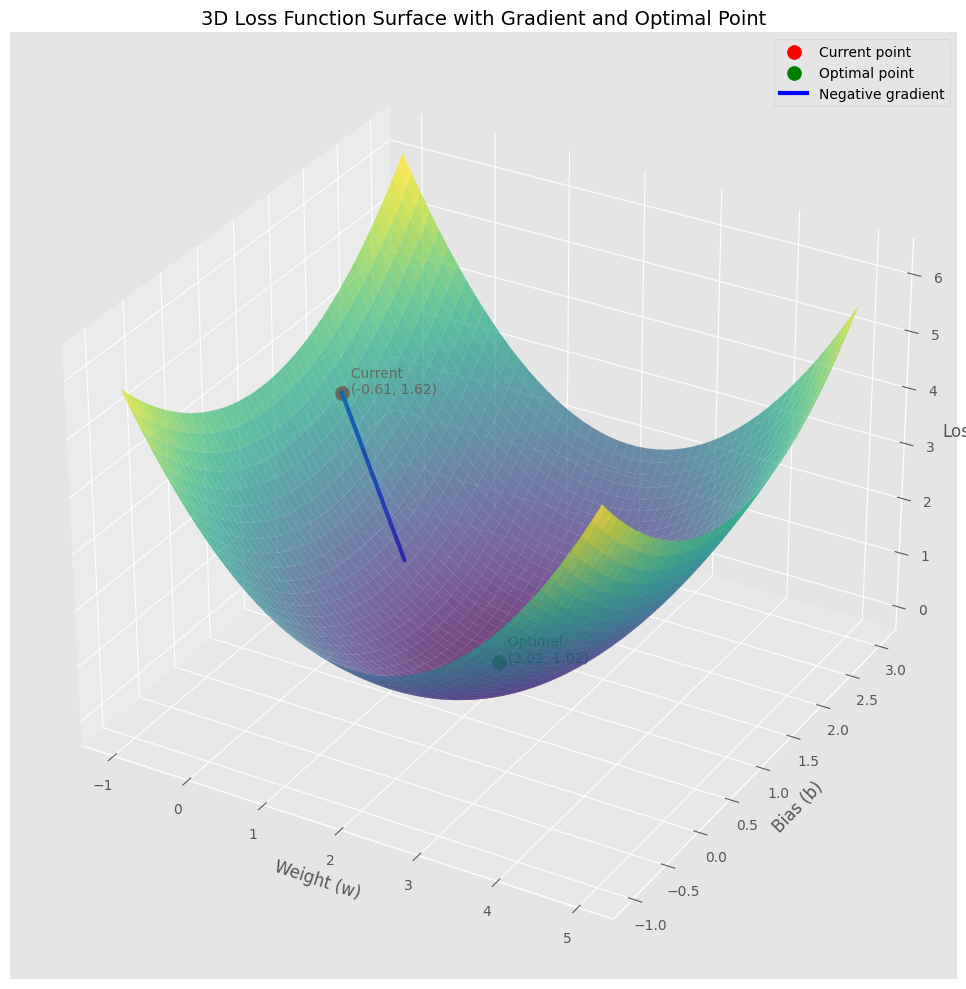

Current w: -0.6118
Current b: 1.6243
Current loss: 3.2609
Gradient w: -2.2990
Gradient b: 0.7137

Optimal w: 2.0202
Optimal b: 1.0180
Optimal loss: 0.0192

True parameters: w=2, b=1


In [104]:
# Calculate gradient at current point
grad_b = error.mean()  # dL/db
grad_w = (error * x).mean()  # dL/dw

# Create grid for 3D plot
b_range = np.linspace(-1, 3, 50)
w_range = np.linspace(-1, 5, 50)
B, W = np.meshgrid(b_range, w_range)

# Calculate loss for each (b,w) pair
Z = np.zeros_like(B)
for i in range(len(b_range)):
    for j in range(len(w_range)):
        y_pred_grid = B[j,i] + W[j,i] * x
        error_grid = y_pred_grid - y
        Z[j,i] = 0.5 * (error_grid ** 2).mean()

# Create 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the loss surface
surf = ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.7)

# Plot the current point
ax.scatter(w, b, loss, color='red', s=100, label='Current point')

# Plot the optimal point (analytical solution)
# For linear regression: w_opt = cov(x,y)/var(x), b_opt = mean(y) - w_opt*mean(x)
x_mean = x.mean()
y_mean = y.mean()
w_opt = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
b_opt = y_mean - w_opt * x_mean

# Calculate optimal loss
y_pred_opt = b_opt + w_opt * x
error_opt = y_pred_opt - y
loss_opt = .5*(error_opt ** 2).mean()

ax.scatter(w_opt, b_opt, loss_opt, color='green', s=100, label='Optimal point')

# Plot gradient line (negative gradient direction)
# Scale the gradient for better visualization
scale = 0.5
grad_line_w = [w[0], w[0] - scale * grad_w]
grad_line_b = [b[0], b[0] - scale * grad_b]

# Calculate loss along gradient line for visualization
grad_line_loss = []
for i in range(2):
    y_pred_grad = grad_line_b[i] + grad_line_w[i] * x
    error_grad = y_pred_grad - y
    loss_grad = .5*(error_grad ** 2).mean()
    grad_line_loss.append(loss_grad)

ax.plot(grad_line_w, grad_line_b, grad_line_loss, color='blue', linewidth=3, label='Negative gradient')

# Add labels and title
ax.set_xlabel('Weight (w)', fontsize=12)
ax.set_ylabel('Bias (b)', fontsize=12)
ax.set_zlabel('Loss', fontsize=12)
ax.set_title('3D Loss Function Surface with Gradient and Optimal Point', fontsize=14)

# Add annotations
ax.text(w[0], b[0], loss, f'  Current\n  ({w[0]:.2f}, {b[0]:.2f})', color='red', fontsize=10)
ax.text(w_opt, b_opt, loss_opt, f'  Optimal\n  ({w_opt:.2f}, {b_opt:.2f})', color='green', fontsize=10)

# Add legend
ax.legend()

plt.tight_layout()
plt.show()

# Print information
print(f"Current w: {w[0]:.4f}")
print(f"Current b: {b[0]:.4f}")
print(f"Current loss: {loss:.4f}")
print(f"Gradient w: {grad_w:.4f}")
print(f"Gradient b: {grad_b:.4f}")
print(f"\nOptimal w: {w_opt:.4f}")
print(f"Optimal b: {b_opt:.4f}")
print(f"Optimal loss: {loss_opt:.4f}")
print(f"\nTrue parameters: w={true_w}, b={true_b}")

In [105]:
w_grad = (error * x).mean()
b_grad = error.mean()
w_grad, b_grad

(np.float64(-2.298963838546912), np.float64(0.7136555560623631))

In [78]:
losses = []

loss =  1.8904464906456884 b =  2.870713498296474 w =  1.5023690719285494


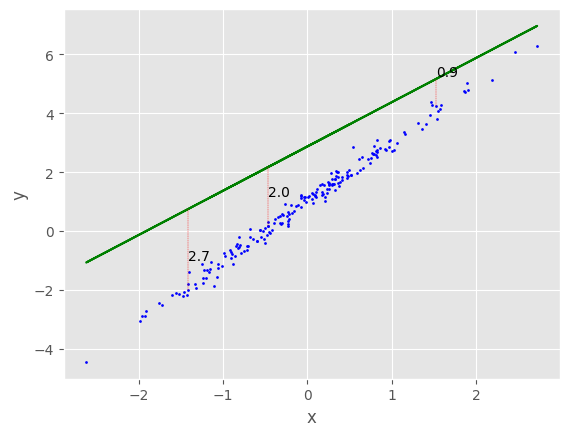

In [96]:
lr = 2
w = w - lr*w_grad
b = b - lr*b_grad
y_pred = b + w * x
plt.scatter(x,y,s=2,c = 'b')
plt.plot(x,y_pred, c = 'g')
for i in [3,10,100]:
    ymin = min([y_pred[i],y[i]])
    ymax = max([y_pred[i],y[i]])
    plt.vlines(x = x[i],ymin = ymin, ymax = ymax,
              colors = 'r',
              label = 'error',
              linestyle = '--',
              linewidth = .3)
    plt.annotate(f'{(ymax - ymin)[0]:0.1f}',xy = (x[i], ymin + 1))
plt.xlabel('x')
plt.ylabel('y')
error = y_pred - y
loss = .5*(error ** 2).mean()
losses.append(loss)
w_grad = (error * x).mean()
b_grad = error.mean()
print('loss = ', loss, 'b = ',b[0],'w = ',w[0])

loss =  0.019553668232452547 b =  1.0166472371555084 w =  1.9919692306939414


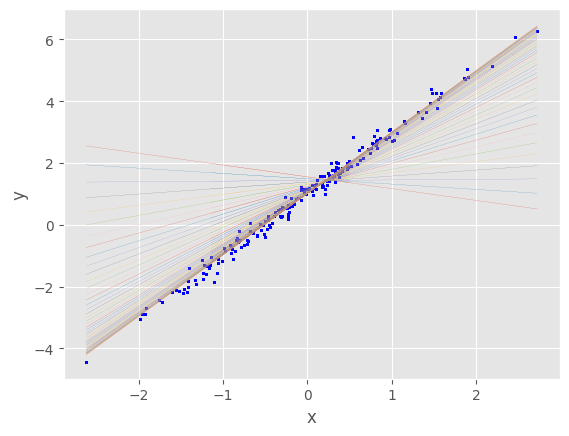

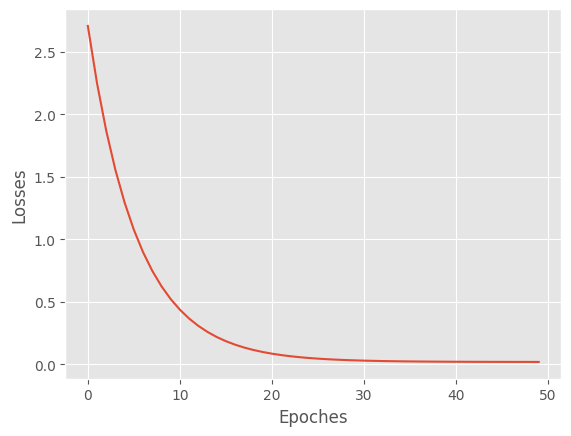

In [106]:
losses = []
epoch = 50
for _ in range(epoch):
    lr = .1
    w = w - lr*w_grad
    b = b - lr*b_grad
    y_pred = b + w * x
    plt.scatter(x,y,s=2,c = 'b')
    plt.plot(x,y_pred, linestyle = '--',linewidth = .1)
    plt.xlabel('x')
    plt.ylabel('y')
    error = y_pred - y
    loss = .5*(error ** 2).mean()
    losses.append(loss)
    w_grad = (error * x).mean()
    b_grad = error.mean()
print('loss = ', loss, 'b = ',b[0],'w = ',w[0])
plt.show()
plt.plot(range(epoch),losses)
plt.xlabel('Epoches')
plt.ylabel('Losses')
plt.show()

Initial: loss = 3.6822, b = 1.6243, w = -0.6118
Epoch 20: loss = 0.0910, b = 1.0403, w = 1.7450
Final: loss = 0.0910, b = 1.0403, w = 1.7450
True parameters: b = 1, w = 2.0


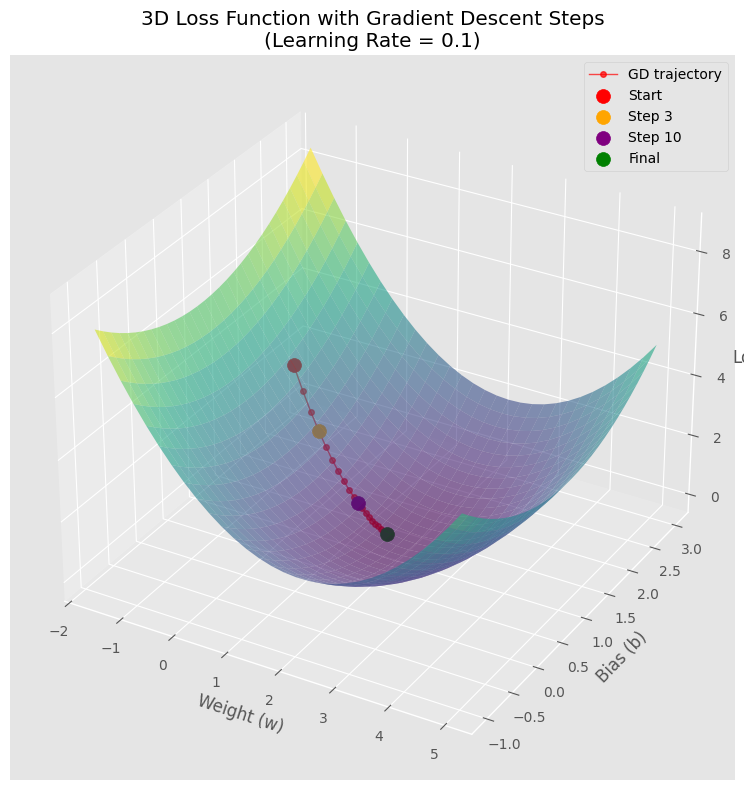

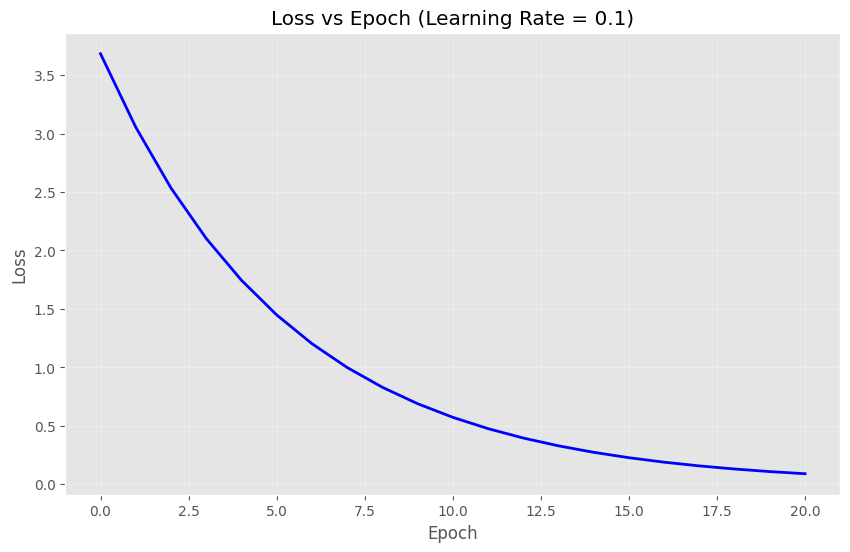


=== SUMMARY ===
True parameters: w = 2.0, b = 1
Final parameters: w = 1.7450, b = 1.0403
Final loss: 0.090990
Learning rate: 0.1
Random state: 1


In [108]:
from plot_gradient import gradient_descent_visualization
result = gradient_descent_visualization(x_train=x,true_w = 2.0,n_epochs = 20, random_state=1, learning_rate=0.1)

Initial: loss = 30.2965, b = 1.6243, w = -0.6118
Final: loss = 20427971383.0478, b = -102.4269, w = 21744.0797
True parameters: b = 1, w = 0.2


d:\Mostafai\deep 1404\s3\plot_gradient.py:179: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


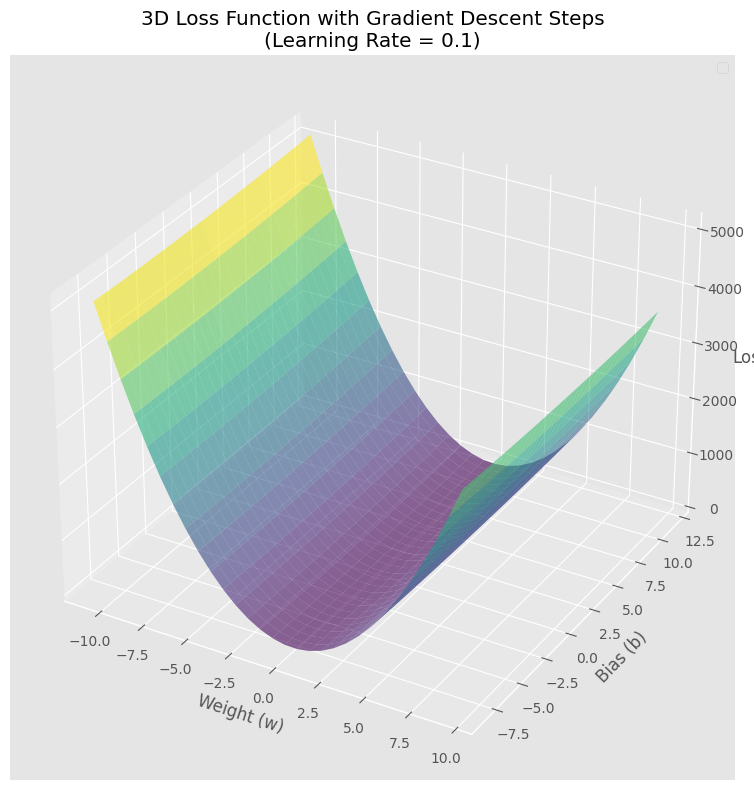

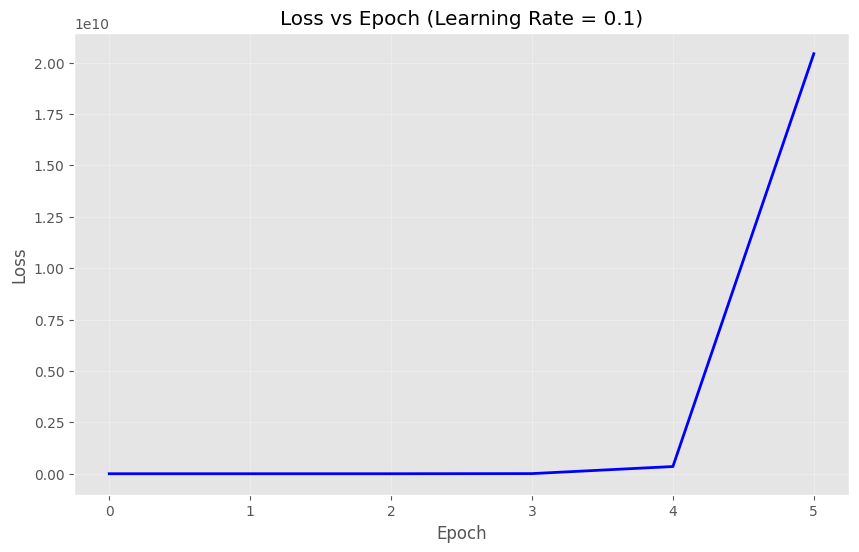


=== SUMMARY ===
True parameters: w = 0.2, b = 1
Final parameters: w = 21744.0797, b = -102.4269
Final loss: 20427971383.047813
Learning rate: 0.1
Random state: 1


In [111]:
bad_w = true_w/10
bad_x = x*10
result = gradient_descent_visualization(x_train=bad_x,true_w = bad_w,n_epochs = 5,
                                         random_state=1, learning_rate=0.1, 
                                         grandient_step=False,
                                         plot_range= 10)

In [112]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
x_mm = mm.fit_transform(bad_x)
x_mm

array([[0.58361597],
       [0.46470424],
       [0.61188878],
       [0.77581301],
       [0.4467472 ],
       [0.44675027],
       [0.78633433],
       [0.63431352],
       [0.40267888],
       [0.59220148],
       [0.40381311],
       [0.40338014],
       [0.53590886],
       [0.13229891],
       [0.16757334],
       [0.38529787],
       [0.30092505],
       [0.54944561],
       [0.32055216],
       [0.22611625],
       [0.76506731],
       [0.44831596],
       [0.50324278],
       [0.22378579],
       [0.38865088],
       [0.5113692 ],
       [0.27505152],
       [0.56095341],
       [0.37811589],
       [0.43597167],
       [0.3779159 ],
       [0.83747099],
       [0.48806924],
       [0.29252046],
       [0.64463395],
       [0.26197077],
       [0.52971051],
       [0.12361153],
       [0.24186887],
       [0.52746284],
       [0.62888869],
       [0.5226888 ],
       [0.46893952],
       [0.43420948],
       [0.21371562],
       [0.3557924 ],
       [0.40433352],
       [0.688

In [113]:
bad_x

array([[  4.96714153],
       [ -1.38264301],
       [  6.47688538],
       [ 15.23029856],
       [ -2.34153375],
       [ -2.34136957],
       [ 15.79212816],
       [  7.67434729],
       [ -4.69474386],
       [  5.42560044],
       [ -4.63417693],
       [ -4.65729754],
       [  2.41962272],
       [-19.13280245],
       [-17.24917833],
       [ -5.62287529],
       [-10.1283112 ],
       [  3.14247333],
       [ -9.08024076],
       [-14.12303701],
       [ 14.65648769],
       [ -2.257763  ],
       [  0.67528205],
       [-14.24748186],
       [ -5.44382725],
       [  1.1092259 ],
       [-11.50993577],
       [  3.75698018],
       [ -6.0063869 ],
       [ -2.9169375 ],
       [ -6.01706612],
       [ 18.52278185],
       [ -0.13497225],
       [-10.57710929],
       [  8.22544912],
       [-12.2084365 ],
       [  2.08863595],
       [-19.59670124],
       [-13.28186049],
       [  1.96861236],
       [  7.3846658 ],
       [  1.71368281],
       [ -1.15648282],
       [ -3

In [114]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_sc = sc.fit_transform(bad_x)
x_sc.mean(),x_sc.std()

(np.float64(1.7763568394002505e-17), np.float64(0.9999999999999998))

Initial: loss = 0.0823, b = 1.6243, w = -0.6118
Final: loss = 0.0636, b = 1.5279, w = -0.6298
True parameters: b = 1, w = 0.2


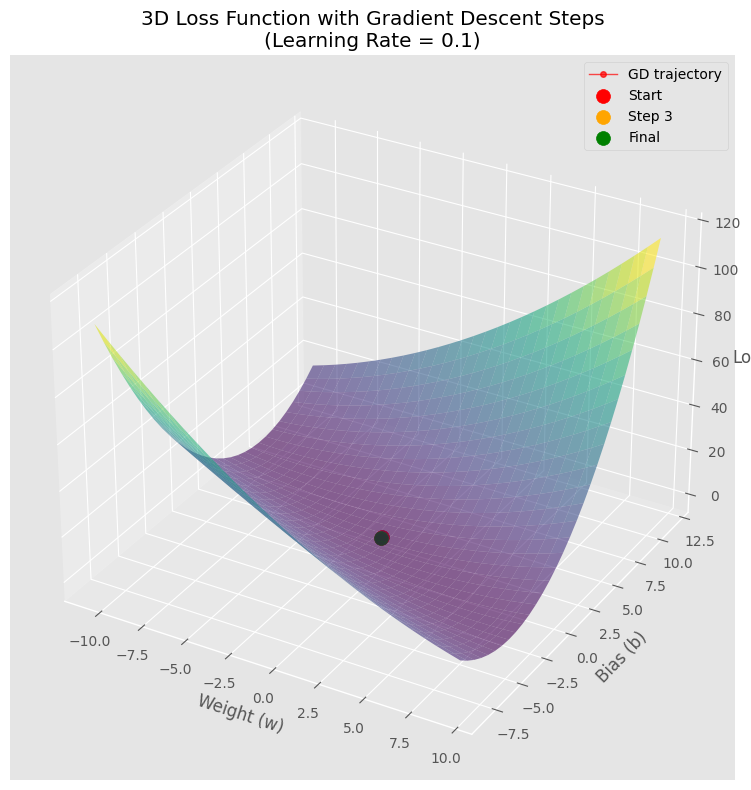

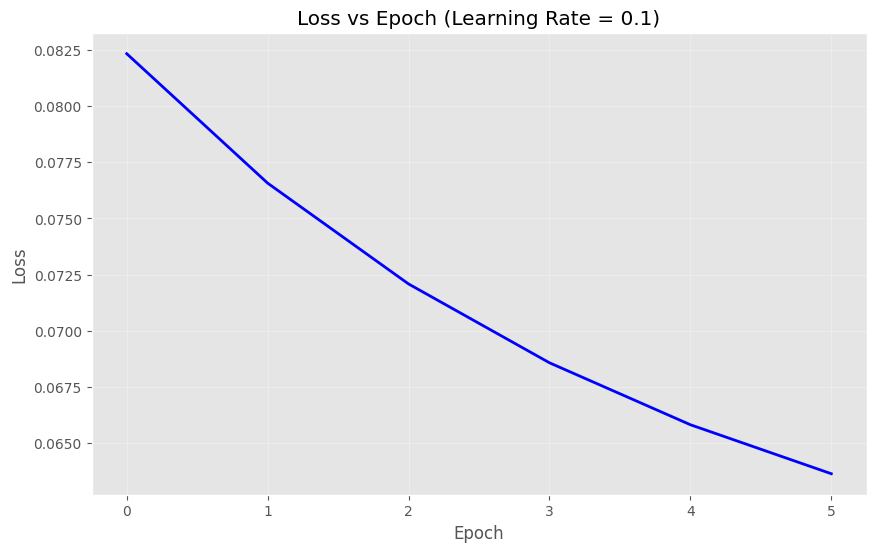


=== SUMMARY ===
True parameters: w = 0.2, b = 1
Final parameters: w = -0.6298, b = 1.5279
Final loss: 0.063618
Learning rate: 0.1
Random state: 1


In [117]:
result = gradient_descent_visualization(x_train=x_mm,true_w = bad_w,n_epochs = 5,
                                         random_state=1, learning_rate=0.1, 
                                         grandient_step=True,
                                         plot_range= 10)

In [120]:
x_train, y_train = x[:160], y[:160]
x_test, y_test = x[160:], y[160:]

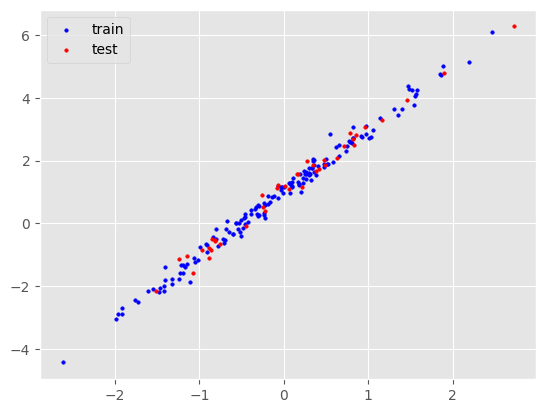

In [121]:
plt.scatter(x_train, y_train, c = 'b', s = 6, label = 'train')
plt.scatter(x_test, y_test, c = 'r', s = 6, label = 'test')
plt.legend()
plt.show()

In [122]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2, random_state= 42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((160, 1), (40, 1), (160, 1), (40, 1))

In [123]:
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor(random_state = 42)
sgd.fit(x_train, y_train)

d:\Mostafai\deep 1404\env\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [124]:
sgd.intercept_

array([1.00589322])

In [126]:
sgd.coef_

array([2.00241615])

In [127]:
y_pred_train = sgd.predict(x_train)

In [129]:
e = y_pred_train - y_train
np.abs(e).mean()

np.float64(2.1291299930742578)

In [130]:
y_pred_test = sgd.predict(x_test)
e = y_pred_test - y_test
np.abs(e).mean()

np.float64(2.008754214855165)